In [22]:
from typing import Dict, List, Tuple
import numpy as np
from pathlib import Path

from model_ranking import (
    load_h5,
)

In [23]:
BCtoBC_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/source_to_source_performance/BBBC039_to_BBBC039_gap/source_performance/P1/BC_IN_model2/norm_50_980/metric_summary.h5"
HNtoHN_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/source_to_source_performance/HeLaNuc_to_HeLaNuc_gap/source_performance/P1/HN_IN_model2/norm_50_996/metric_summary.h5"
HsttoHst_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/source_to_source_performance/Hoechst_to_Hoechst_gap/source_performance/P1/Hst_IN_model3/norm_50_980/metric_summary.h5"
S895toS895_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/source_to_source_performance/S_BIAD895_to_S_BIAD895_gap/source_performance/P1/895_IN_model2/norm_50_980/metric_summary.h5"
summary_paths = {
    "BC_IN_model2": BCtoBC_path, 
    "HN_IN_model2": HNtoHN_path, 
    "Hst_IN_model3": HsttoHst_path, 
    "895_IN_model2": S895toS895_path
}
perf_key = "MAP_05_095"

In [24]:
source_to_source_perf: Dict[str, float] = {}
for model, path in summary_paths.items():
    print(f"Model: {model}")
    perf_score = load_h5(path, f"{perf_key}_median")
    source_to_source_perf[model] = float(perf_score)

Model: BC_IN_model2
Model: HN_IN_model2
Model: Hst_IN_model3
Model: 895_IN_model2


In [25]:
source_to_source_perf

{'BC_IN_model2': 0.7581373453140259,
 'HN_IN_model2': 0.529358446598053,
 'Hst_IN_model3': 0.7061910629272461,
 '895_IN_model2': 0.6318672895431519}

In [26]:
from numpy.typing import NDArray
from typing import Any, List


S1410toS1410_base_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/source_to_source_performance/S_BIAD1410_to_S_BIAD1410_gap/source_performance/P1/1410_IN_model1/norm_5_98/predictions")
pred_paths = list(S1410toS1410_base_path.glob("*.h5"))


sep_perfs: List[NDArray[Any]] = []
for pred_path in pred_paths:
    perf = load_h5(pred_path, perf_key)
    sep_perfs.append(perf)
cmb_perfs = np.concatenate(sep_perfs)
    
S1410_cmb_perf_median = float(np.median(cmb_perfs))
print(f"S1410 performance: {S1410_cmb_perf_median}")

S1410 performance: 0.6771903038024902


In [27]:
source_to_source_perf["1410_IN_model1"] = S1410_cmb_perf_median

In [ ]:
targets = ["BBBC039", "Hoechst", "S_BIAD895", "S_BIAD634"]
per_target_source_performance: Dict[str, Dict[str, float]] = {}
for target in targets:
    if target == "S_BIAD895":
        stos_perf = source_to_source_perf.copy()
        _ = stos_perf.pop("895_IN_model2")
        per_target_source_performance[target] = stos_perf
    else:
        per_target_source_performance[target] = source_to_source_perf

In [29]:
per_target_source_performance

{'BBBC039': {'BC_IN_model2': 0.7581373453140259,
  'HN_IN_model2': 0.529358446598053,
  'Hst_IN_model3': 0.7061910629272461,
  '895_IN_model2': 0.6318672895431519,
  '1410_IN_model1': 0.6771903038024902},
 'Hoechst': {'BC_IN_model2': 0.7581373453140259,
  'HN_IN_model2': 0.529358446598053,
  'Hst_IN_model3': 0.7061910629272461,
  '895_IN_model2': 0.6318672895431519,
  '1410_IN_model1': 0.6771903038024902},
 'S_BIAD895': {'BC_IN_model2': 0.7581373453140259,
  'HN_IN_model2': 0.529358446598053,
  'Hst_IN_model3': 0.7061910629272461,
  '1410_IN_model1': 0.6771903038024902},
 'S_BIAD634': {'BC_IN_model2': 0.7581373453140259,
  'HN_IN_model2': 0.529358446598053,
  'Hst_IN_model3': 0.7061910629272461,
  '895_IN_model2': 0.6318672895431519,
  '1410_IN_model1': 0.6771903038024902}}

In [30]:
import json
import os
from model_ranking.results import convert_numpy_types
from typing import Any

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# for i, alpha in enumerate(selected_augmentations['gauss']):
#     per_target_consistency: Dict[str, Dict[str,float]] = {}
#     for target, per_model_consistency in per_target_forg_consistency.items():
#         per_target_consistency[target] = {}
#         for model, consistency in per_model_consistency.items():
#             per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

#     with open(os.path.join(save_path, f"transfer_self_supervised_Gauss_{alpha}_FORG_ARE_scores.json"), "w") as f:
#         results: Dict[str, Any] = {
#             "transfer_scores": convert_numpy_types(per_target_consistency),
#         }
#         json.dump(results, f, indent=4)

with open(os.path.join(save_path, f"direct_source_performance_score_as_transfer_metric.json"), "w") as f:
    results: Dict[str, Any] = {
        "transfer_scores": convert_numpy_types(per_target_source_performance),
    }
    json.dump(results, f, indent=4)


In [31]:
import json

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    avg_correlation_table,
)

In [32]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Processing: Direct Source Performance
Number of targets: 4
  Target 1: BBBC039
  Target 2: Hoechst
  Target 3: S_BIAD895
  Target 4: S_BIAD634


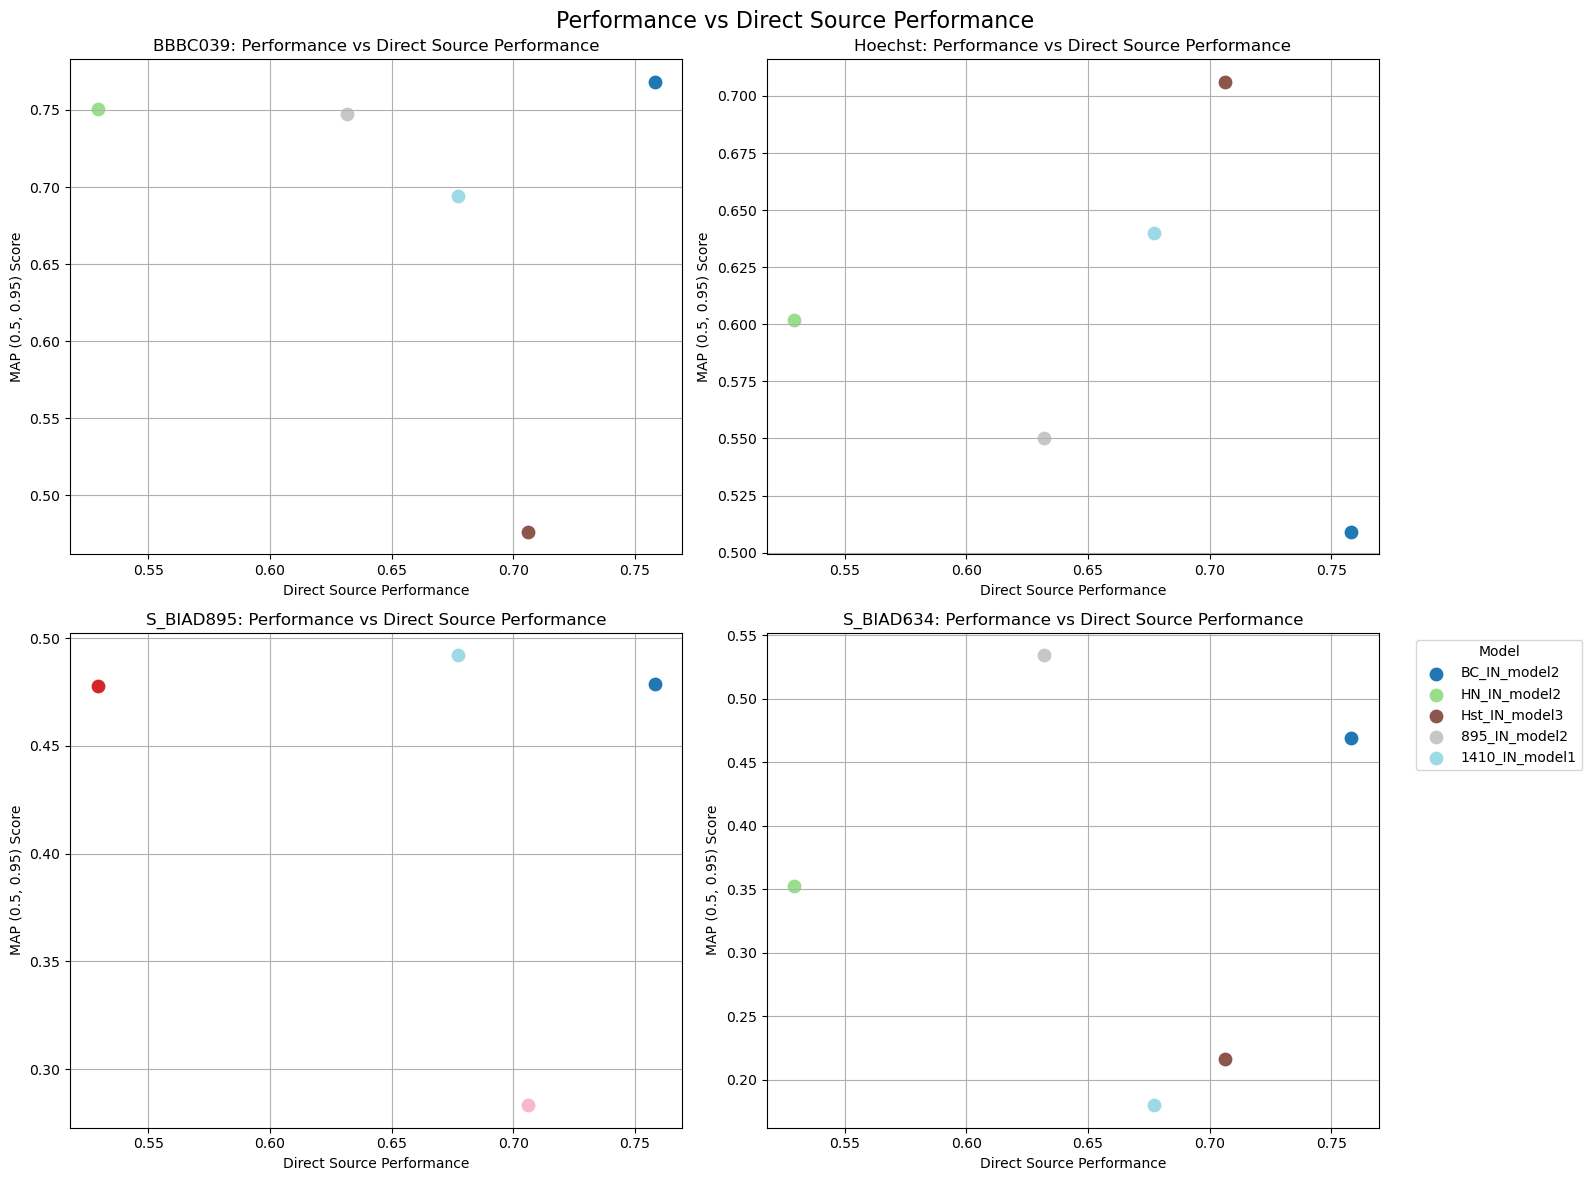

                 kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                  
Mito BBBC039   -0.2     0.82    0.0        1.00 -0.28     0.65
     Hoechst    0.0     1.00   -0.1        0.86 -0.08     0.89
     S_BIAD895  0.0     1.00    0.0        1.00 -0.25     0.75
     S_BIAD634  0.0     1.00   -0.1        0.94 -0.05     0.93
      KT_avg  KT_std  SR_avg    SR_std  PR_avg    PR_std
Task                                                    
Mito   -0.05     0.1   -0.05  0.057735  -0.165  0.116762


In [33]:
transfer_score_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/direct_source_performance_score_as_transfer_metric.json"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

plot_performance_vs_transfer_metric_multi_target(
    performance_scores=performance_scores,
        transfer_scores=per_target_source_performance,
        transfer_metric=f"Direct Source Performance",
        invert_transfer_metric=False,
        finetuned=False,
        performance_metric_key="MAP (0.5, 0.95)",
    )
KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
    targets=targets,
    transfer_metric_per_target=per_target_source_performance,
    performance_per_target=performance_scores,
    invert_transfer_metric=False,
)
cells_correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
print(cells_correlation_df)
df_cells_avg = avg_correlation_table(cells_correlation_df)
print(df_cells_avg)